# Day 18 — Category Analysis & Feature Importance

## EduPro Predictive Modeling

### Objective

Analyze course performance by category and identify the most
important features influencing the final revenue prediction model.

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
import joblib

import matplotlib.pyplot as plt

In [2]:
project_folder = Path(
    r"D:\Data Analytics Project\EduPro_Predictive_Modeling"
)

model_folder = project_folder / "models"
data_folder = project_folder / "data"
notebook_folder = project_folder / "notebooks"

revenue_model_path = (
    model_folder /
    "EduPro_Final_Revenue_Model.joblib"
)

print("Project:", project_folder)
print("Revenue model:", revenue_model_path)

Project: D:\Data Analytics Project\EduPro_Predictive_Modeling
Revenue model: D:\Data Analytics Project\EduPro_Predictive_Modeling\models\EduPro_Final_Revenue_Model.joblib


## Load Final Revenue Model

In [3]:
revenue_model = joblib.load(
    revenue_model_path
)

print("Model type:", type(revenue_model))

Model type: <class 'sklearn.pipeline.Pipeline'>


## Define MOdeling Features

In [4]:
revenue_features = [
    "CourseCategory",
    "CourseType",
    "CourseLevel",
    "CoursePrice",
    "CourseDuration",
    "CourseRating",
    "TeacherRating",
    "YearsOfExperience",
    "Expertise"
]

print("Number of features:", len(revenue_features))
print(revenue_features)

Number of features: 9
['CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating', 'TeacherRating', 'YearsOfExperience', 'Expertise']


## Load the Category Analysis Dataset

In [5]:
prediction_file = (
    data_folder /
    "feature_data" /
    "EduPro_Day8_Prediction_Targets.xlsx"
)

category_data = pd.read_excel(
    prediction_file,
    sheet_name="Prediction_Targets"
)

print("Shape:", category_data.shape)
display(category_data.head())

Shape: (60, 15)


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherID,TeacherName,TeacherRating,YearsOfExperience,Expertise,EnrollmentCount,CourseRevenue
0,CR00050,Computer Vision,Artificial Intelligence,Paid,Beginner,490.9,7.55,4.55,TC00040,Kimberly Miller,4.58,24,Cybersecurity,174,85416.6
1,CR00021,Data Analysis with Python,Data Science,Free,Intermediate,0.0,1.20,3.60,TC00016,David Carlson,2.92,1,Data Science,196,0.0
2,CR00009,Web Design Fundamentals,Design,Free,Beginner,0.0,48.19,4.51,TC00051,John Obrien,1.77,2,Design,155,0.0
3,CR00022,Data Visualization,Data Science,Free,Beginner,0.0,32.64,3.65,TC00010,Frances Sanchez,2.18,1,Data Science,177,0.0
4,CR00027,Neural Networks,Machine Learning,Free,Advanced,0.0,9.30,1.81,TC00036,Brenda Mclean,1.39,4,Digital Marketing,152,0.0


## Validate the Data

In [6]:
print("Missing values:")
print(category_data.isnull().sum())

print("\nCategories:")
print(category_data["CourseCategory"].unique())

print("\nNumber of categories:")
print(category_data["CourseCategory"].nunique())

Missing values:
CourseID             0
CourseName           0
CourseCategory       0
CourseType           0
CourseLevel          0
CoursePrice          0
CourseDuration       0
CourseRating         0
TeacherID            0
TeacherName          0
TeacherRating        0
YearsOfExperience    0
Expertise            0
EnrollmentCount      0
CourseRevenue        0
dtype: int64

Categories:
<ArrowStringArray>
['Artificial Intelligence',            'Data Science',
                  'Design',        'Machine Learning',
      'Project Management',               'Marketing',
       'Digital Marketing',         'Web Development',
             'Programming',                'Business',
                 'Finance',           'Cybersecurity']
Length: 12, dtype: str

Number of categories:
12


In [7]:
required_columns = [
    "CourseCategory",
    "EnrollmentCount",
    "CourseRevenue"
]

missing_columns = [
    col for col in required_columns
    if col not in category_data.columns
]

print("Missing required columns:", missing_columns)

Missing required columns: []


## Category Performance Analysis

In [8]:
category_summary = (
    category_data
    .groupby("CourseCategory")
    .agg(
        CourseCount=("CourseID", "count"),
        TotalRevenue=("CourseRevenue", "sum"),
        AverageRevenue=("CourseRevenue", "mean"),
        AverageEnrollment=("EnrollmentCount", "mean")
    )
    .reset_index()
)

category_summary = category_summary.sort_values(
    "TotalRevenue",
    ascending=False
)

display(category_summary)

,CourseCategory,CourseCount,TotalRevenue,AverageRevenue,AverageEnrollment
0,Artificial Intelligence,5,202750.67,40550.134,165.8
1,Business,5,181527.58,36305.516,166.6
10,Project Management,5,169103.21,33820.642,165.8
9,Programming,5,77453.92,15490.784,161.2
3,Data Science,5,77052.32,15410.464,183.2
2,Cybersecurity,5,59139.00,11827.800,163.8
5,Digital Marketing,5,56261.32,11252.264,161.6
4,Design,5,43113.72,8622.744,165.4
6,Finance,5,28106.20,5621.240,172.8
11,Web Development,5,16682.15,3336.430,168.8


## Category Revenue Ranking

In [9]:
category_revenue_ranking = (
    category_summary[
        [
            "CourseCategory",
            "TotalRevenue",
            "AverageRevenue"
        ]
    ]
    .sort_values(
        "TotalRevenue",
        ascending=False
    )
    .reset_index(drop=True)
)

category_revenue_ranking["RevenueRank"] = (
    category_revenue_ranking.index + 1
)

display(category_revenue_ranking)

,CourseCategory,TotalRevenue,AverageRevenue,RevenueRank
0,Artificial Intelligence,202750.67,40550.134,1
1,Business,181527.58,36305.516,2
2,Project Management,169103.21,33820.642,3
3,Programming,77453.92,15490.784,4
4,Data Science,77052.32,15410.464,5
5,Cybersecurity,59139.00,11827.800,6
6,Digital Marketing,56261.32,11252.264,7
7,Design,43113.72,8622.744,8
8,Finance,28106.20,5621.240,9
9,Web Development,16682.15,3336.430,10


## Best & Lowest Performing Categories  

In [10]:
best_category = category_summary.iloc[0]

lowest_category = (
    category_summary
    .sort_values("TotalRevenue", ascending=True)
    .iloc[0]
)

print("Best Category:")
print(best_category)

print("\nLowest Revenue Category:")
print(lowest_category)

Best Category:
CourseCategory       Artificial Intelligence
CourseCount                                5
TotalRevenue                       202750.67
AverageRevenue                     40550.134
AverageEnrollment                      165.8
Name: 0, dtype: object

Lowest Revenue Category:
CourseCategory       Marketing
CourseCount                  5
TotalRevenue               0.0
AverageRevenue             0.0
AverageEnrollment        161.2
Name: 8, dtype: object


In [11]:
print(
    f"Highest total revenue category: "
    f"{best_category['CourseCategory']}"
)

print(
    f"Lowest total revenue category: "
    f"{lowest_category['CourseCategory']}"
)

Highest total revenue category: Artificial Intelligence
Lowest total revenue category: Marketing


## Category Revenue Visualization

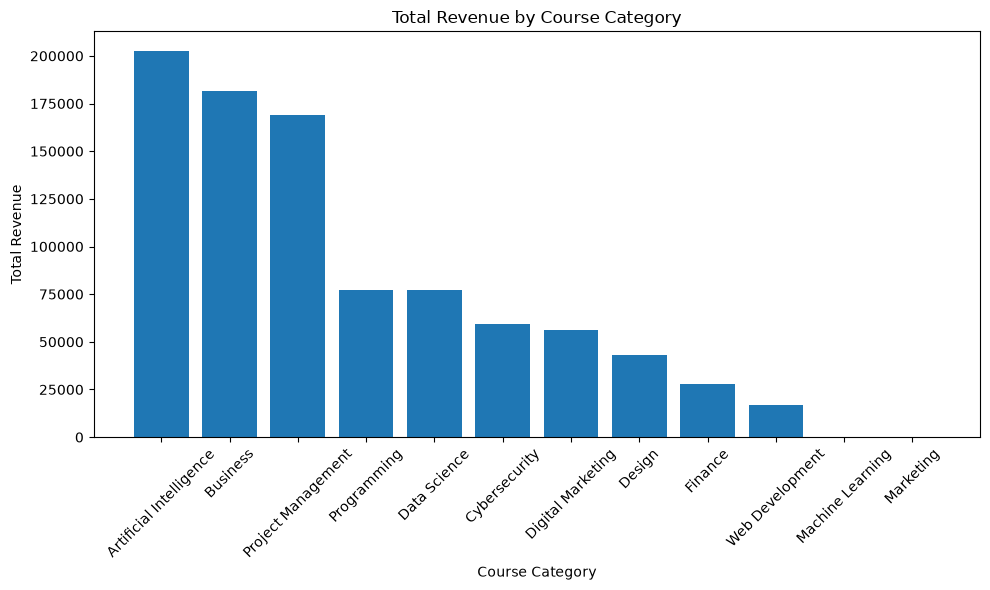

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_summary["CourseCategory"],
    category_summary["TotalRevenue"]
)

plt.title("Total Revenue by Course Category")
plt.xlabel("Course Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Extract Feature Importance

In [14]:
print(revenue_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['CourseCategory',
                                                   'CourseType', 'CourseLevel',
                                                   'Expertise']),
                                                 ('numerical', 'passthrough',
                                                  ['CoursePrice',
                                                   'CourseDuration',
                                                   'CourseRating',
                                                   'TeacherRating',
                                                   'YearsOfExperience'])])),
                ('model', LinearRegression())])


In [15]:
print(
    revenue_model.named_steps
)

{'preprocessor': ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['CourseCategory', 'CourseType', 'CourseLevel',
                                  'Expertise']),
                                ('numerical', 'passthrough',
                                 ['CoursePrice', 'CourseDuration',
                                  'CourseRating', 'TeacherRating',
                                  'YearsOfExperience'])]), 'model': LinearRegression()}


## Identify the Model & Preprocessor

In [16]:
for name, step in revenue_model.named_steps.items():
    print(name, "->", type(step))

preprocessor -> <class 'sklearn.compose._column_transformer.ColumnTransformer'>
model -> <class 'sklearn.linear_model._base.LinearRegression'>


## Get Transformed Feature Names

In [19]:
# ============================================================
# CELL 14 — EXTRACT TRANSFORMED FEATURE NAMES
# ============================================================

print("Pipeline steps:")
print(revenue_model.named_steps)

# Find the preprocessing step automatically
preprocessor = None

for step_name, step in revenue_model.named_steps.items():
    if hasattr(step, "get_feature_names_out"):
        preprocessor = step
        print("\nPreprocessor found:", step_name)
        break

if preprocessor is None:
    raise ValueError(
        "Could not find a preprocessing step with "
        "'get_feature_names_out()'."
    )

# Extract transformed feature names
feature_names = preprocessor.get_feature_names_out()

print("\nTransformed feature count:", len(feature_names))

print("\nTransformed Features:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Pipeline steps:
{'preprocessor': ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['CourseCategory', 'CourseType', 'CourseLevel',
                                  'Expertise']),
                                ('numerical', 'passthrough',
                                 ['CoursePrice', 'CourseDuration',
                                  'CourseRating', 'TeacherRating',
                                  'YearsOfExperience'])]), 'model': LinearRegression()}

Preprocessor found: preprocessor

Transformed feature count: 34

Transformed Features:
1. categorical__CourseCategory_Artificial Intelligence
2. categorical__CourseCategory_Business
3. categorical__CourseCategory_Cybersecurity
4. categorical__CourseCategory_Data Science
5. categorical__CourseCategory_Design
6. categorical__CourseCategory_Digital Marketing
7. cat

## Feature Importance Table

In [21]:
# ============================================================
# CELL 15 — CALCULATE FEATURE IMPORTANCE
# ============================================================

# Find the final estimator inside the pipeline
final_model = revenue_model.steps[-1][1]
final_model_name = revenue_model.steps[-1][0]

print("Final model step:", final_model_name)
print("Final model type:", type(final_model).__name__)


# ============================================================
# 1. TREE-BASED MODEL
# ============================================================

if hasattr(final_model, "feature_importances_"):

    print("\nImportance method: feature_importances_")

    importances = final_model.feature_importances_

    importance_method = "Feature Importance"


# ============================================================
# 2. LINEAR MODEL
# ============================================================

elif hasattr(final_model, "coef_"):

    print("\nImportance method: model coefficients")

    coefficients = np.asarray(
        final_model.coef_
    )

    # Handle single-output regression
    if coefficients.ndim == 1:
        importances = np.abs(coefficients)

    # Handle multi-output regression
    else:
        importances = np.mean(
            np.abs(coefficients),
            axis=0
        )

    importance_method = "Absolute Coefficient"


# ============================================================
# 3. MODEL NOT SUPPORTED
# ============================================================

else:

    raise ValueError(
        "The final model does not provide either "
        "'feature_importances_' or 'coef_'. "
        f"Model type: {type(final_model).__name__}"
    )


# ============================================================
# 4. VERIFY FEATURE COUNTS
# ============================================================

print(
    "\nNumber of importance values:",
    len(importances)
)

print(
    "Number of transformed features:",
    len(feature_names)
)


if len(importances) != len(feature_names):

    raise ValueError(
        "The number of importance values does not match "
        "the number of transformed feature names."
    )


# ============================================================
# 5. CREATE FEATURE IMPORTANCE DATAFRAME
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})


# ============================================================
# 6. SORT FEATURES
# ============================================================

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 7. ADD RANK
# ============================================================

feature_importance.insert(
    0,
    "Rank",
    range(
        1,
        len(feature_importance) + 1
    )
)


# ============================================================
# 8. DISPLAY RESULTS
# ============================================================

print("\nFeature Importance Ranking:")
print(
    f"Method used: {importance_method}"
)

display(feature_importance)

Final model step: model
Final model type: LinearRegression

Importance method: model coefficients

Number of importance values: 34
Number of transformed features: 34

Feature Importance Ranking:
Method used: Absolute Coefficient


,Rank,Feature,Importance
0,1,categorical__CourseCategory_Digital Marketing,2648.390241
1,2,categorical__CourseCategory_Design,2276.247148
2,3,categorical__Expertise_Cybersecurity,2028.125664
3,4,categorical__Expertise_Design,1711.383291
4,5,categorical__Expertise_Business,1693.136229
5,6,categorical__Expertise_Artificial Intelligence,1637.415998
6,7,categorical__Expertise_Digital Marketing,1132.790060
7,8,categorical__CourseCategory_Data Science,1077.516390
8,9,categorical__Expertise_Project Management,1072.867966
9,10,categorical__Expertise_Web Development,1054.139427


## Feature Importance Visualization

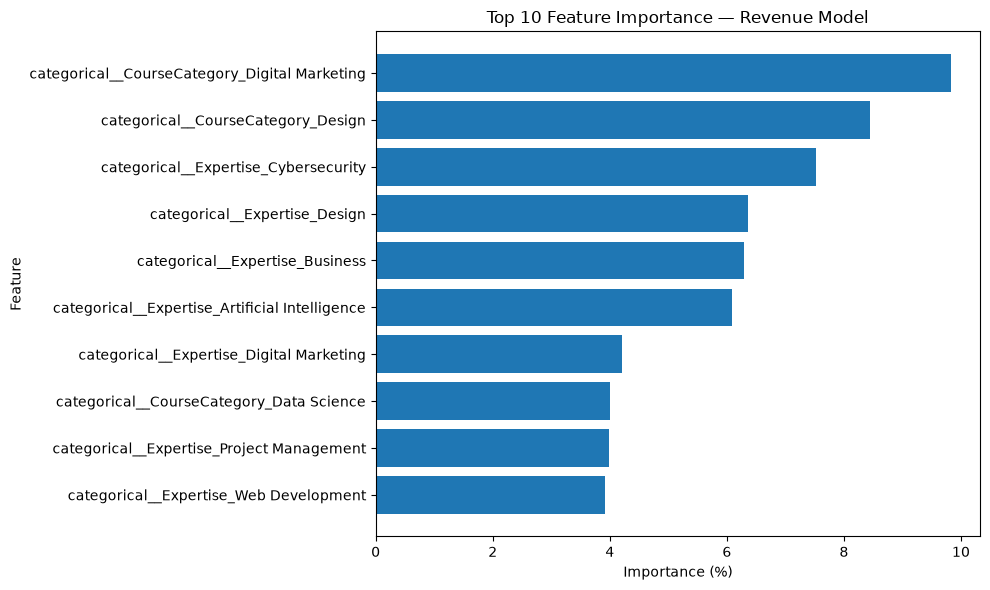

In [22]:
# ============================================================
# CELL 16 — FEATURE IMPORTANCE VISUALIZATION
# ============================================================

# Select top 10 features
top_features = (
    feature_importance
    .head(10)
    .copy()
)

# Convert importance to percentage
top_features["Importance_Percent"] = (
    top_features["Importance"]
    / feature_importance["Importance"].sum()
) * 100

# Sort for horizontal bar chart
top_features = (
    top_features
    .sort_values(
        "Importance_Percent",
        ascending=True
    )
)

# Create visualization
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance_Percent"]
)

plt.title(
    "Top 10 Feature Importance — Revenue Model"
)

plt.xlabel(
    "Importance (%)"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

# Business Insights

## Category Analysis

The category analysis identifies which course categories generate
the strongest overall revenue and which categories require further
review.

## Feature Importance

Feature importance identifies the variables that contribute most
strongly to the final revenue model's predictions.

## Business Implications

1. Prioritize high-performing categories for new course launches.
2. Review pricing strategy for categories with weaker revenue.
3. Use highly important model features when evaluating new courses.
4. Consider course characteristics and instructor-related factors
   when making launch decisions.
5. Use feature importance as a decision-support tool rather than
   treating it as causal evidence.